In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os
import glob
import numpy as np
import pandas as pd


folder = "main_folder"  
# например:
# folder = r"C:\Users\Ivan\Desktop\kinetics"
# folder = "/Users/ivan/Desktop/kinetics"
folder = "kinetika/CData/"


files = sorted(glob.glob(os.path.join(folder, "IV*.csv")))

print("Найденные файлы:")
for file in files:
    print(file)


def read_iv_file(path):
    name = os.path.splitext(os.path.basename(path))[0]

    df = pd.read_csv(path)

    # В твоих файлах время оказалось в индексе,
    # поэтому возвращаем индекс в обычный столбец
    df = df.reset_index()

    # Берем первые два столбца: время и оптическую плотность
    df = df.iloc[:, :2].copy()
    df.columns = ["Time_Sec", name]

    # На всякий случай заменяем десятичные запятые на точки
    df["Time_Sec"] = df["Time_Sec"].astype(str).str.replace(",", ".", regex=False)
    df[name] = df[name].astype(str).str.replace(",", ".", regex=False)

    # Переводим в числа
    df["Time_Sec"] = pd.to_numeric(df["Time_Sec"], errors="coerce")
    df[name] = pd.to_numeric(df[name], errors="coerce")

    # Убираем строки с мусором
    df = df.dropna(subset=["Time_Sec", name])

    return df


tables = [read_iv_file(file) for file in files]

merged = tables[0]

for table in tables[1:]:
    merged = pd.merge(
        merged,
        table,
        on="Time_Sec",
        how="outer"
    )

merged = merged.sort_values("Time_Sec").reset_index(drop=True)

# numpy-массивы
time_np = merged["Time_Sec"].to_numpy()
values_np = merged.drop(columns=["Time_Sec"]).to_numpy()
data_np = merged.to_numpy()

print("\nИтоговая таблица:")
print(merged.head())

print("\nРазмер data_np:", data_np.shape)
print("Размер time_np:", time_np.shape)
print("Размер values_np:", values_np.shape)

# сохранение
merged.to_csv(os.path.join(folder, "IV_merged.csv"), index=False)
np.save(os.path.join(folder, "IV_merged.npy"), data_np)
np.save(os.path.join(folder, "IV_time.npy"), time_np)
np.save(os.path.join(folder, "IV_values.npy"), values_np)

Найденные файлы:
kinetika/CData/IV1_1.csv
kinetika/CData/IV1_1REA.csv
kinetika/CData/IV1_2.csv
kinetika/CData/IV1_4.csv
kinetika/CData/IV1_5.csv
kinetika/CData/IV1_6.csv
kinetika/CData/IV21.csv
kinetika/CData/IV22.csv
kinetika/CData/IV23.csv
kinetika/CData/IV24.csv
kinetika/CData/IV25.csv
kinetika/CData/IV26.csv

Итоговая таблица:
   Time_Sec   IV1_1  IV1_1REA   IV1_2   IV1_4   IV1_5   IV1_6    IV21    IV22  \
0       0.0  1.8180    2.0003  1.9058  1.8500  1.8066  2.0503  1.8420  1.9715   
1       2.0  1.8017    1.9939  1.8944  1.8255  1.7771  2.0062  1.8339  1.9557   
2       4.0  1.7872    1.9891  1.8829  1.8026  1.7463  1.9634  1.8247  1.9406   
3       6.0  1.7803    1.9871  1.8722  1.7775  1.7191  1.9225  1.8153  1.9242   
4       8.0  1.7861    1.9893  1.8619  1.7503  1.6976  1.8836  1.8062  1.9063   

     IV23    IV24    IV25    IV26  
0  1.9367  1.6975  1.9620  2.1157  
1  1.9180  1.6886  1.9450  2.0934  
2  1.9013  1.6790  1.9290  2.0736  
3  1.8839  1.6686  1.9137  2.0563  


In [38]:
folder = "kinetika/CData/"  # папка с файлами; можно заменить на свой путь

files = sorted(glob.glob(os.path.join(folder, "IV*.csv")))
pd.read_csv(files[0]).columns[0]

'IV1_1.TMC'

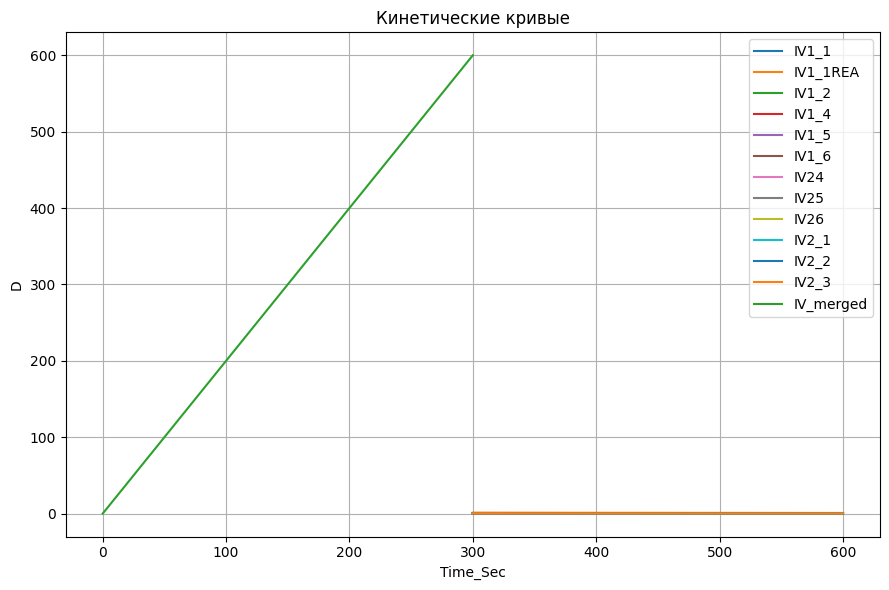

In [40]:
import os
import pandas as pd
import matplotlib.pyplot as plt


merged_path = os.path.join(folder, "IV_merged.csv")
merged = pd.read_csv(merged_path)

# x — первый столбец
x = merged.iloc[:, 0]

# y — все остальные столбцы
ys = merged.iloc[:, 1:]

plt.figure(figsize=(9, 6))

for column in ys.columns:
    plt.plot(x, ys[column], label=column)

plt.xlabel(merged.columns[0])
plt.ylabel("D")
plt.title("Кинетические кривые")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Столбец времени: Time_Sec
Столбцы D(t):
IV1_1
IV1_1REA
IV1_2
IV1_4
IV1_5
IV1_6
IV24
IV25
IV26
IV2_1
IV2_2
IV2_3
IV_merged
IV1_1: C = 0.10 M, k1 = 0.003369 1/c, R^2 = 0.9662
IV1_2: C = 0.15 M, k1 = 0.002544 1/c, R^2 = 0.9867
IV1_4: C = 0.20 M, k1 = 0.004056 1/c, R^2 = 0.9222
IV1_5: C = 0.25 M, k1 = 0.004250 1/c, R^2 = 0.8734
IV1_6: C = 0.30 M, k1 = 0.004175 1/c, R^2 = 0.8132


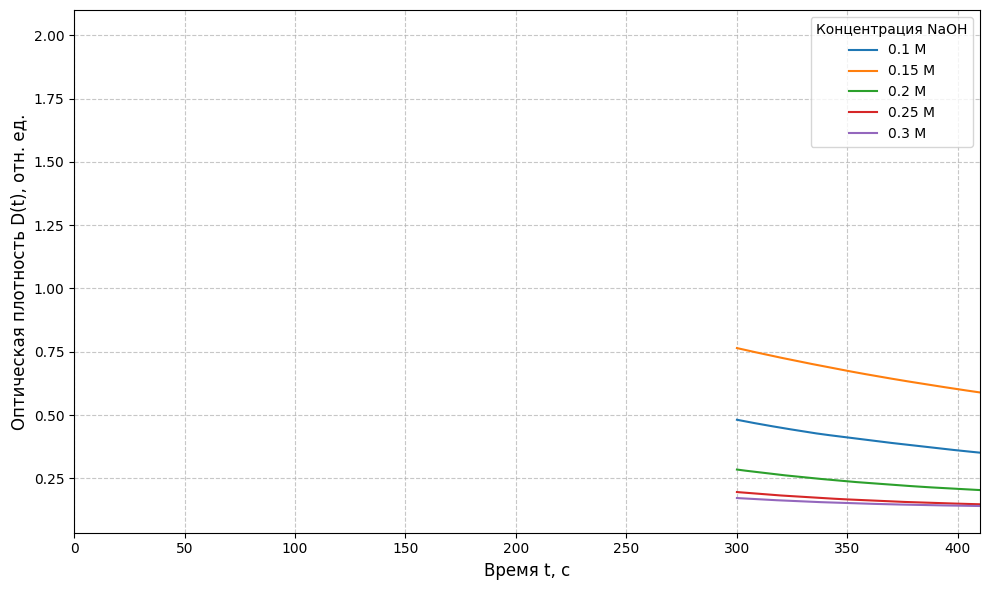

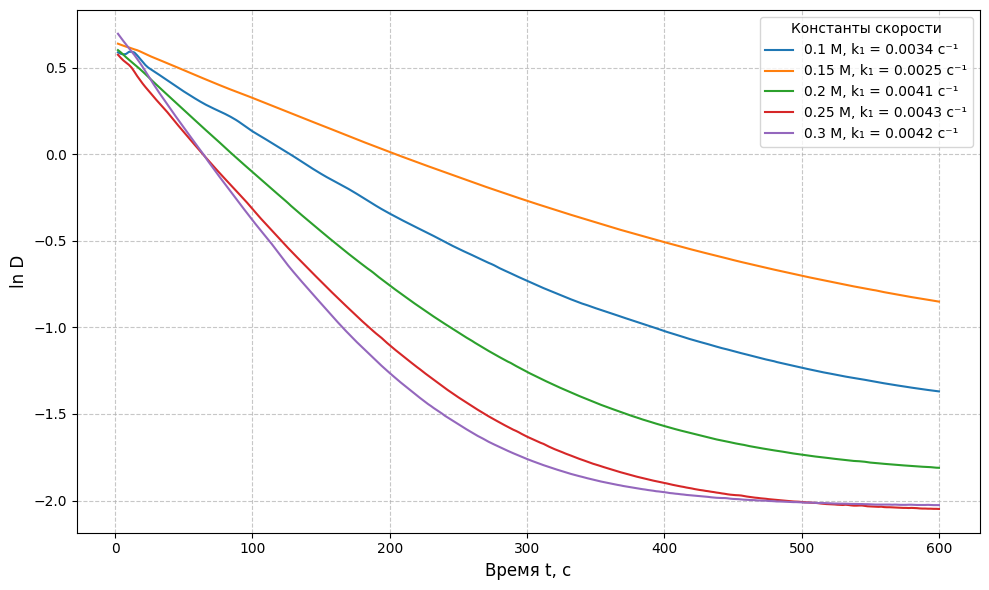

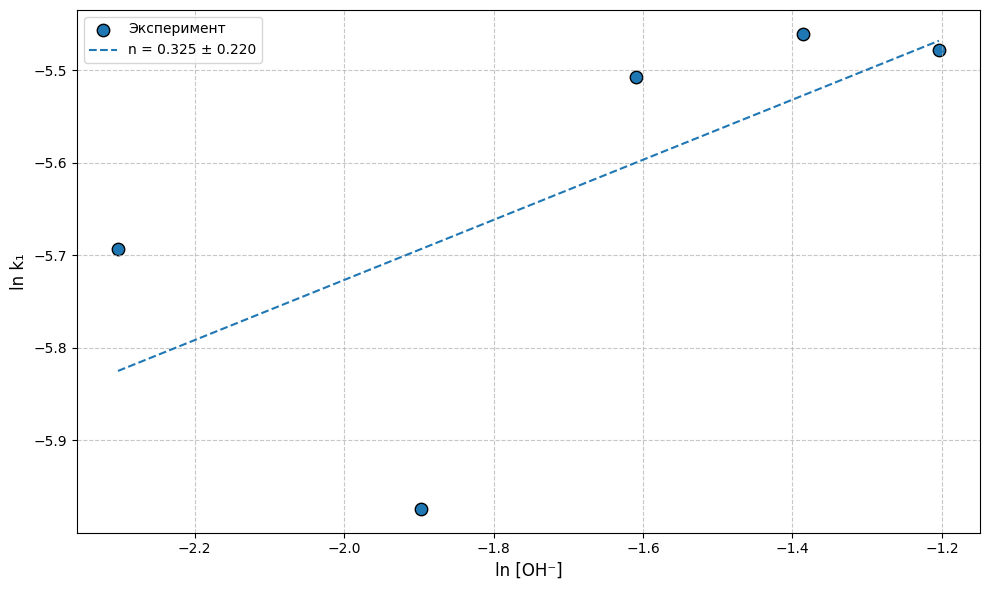


Результаты:
n = 0.325 ± 0.220
k2 = 0.006236 ± 0.002366 М⁻¹·с⁻¹


In [43]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress


# Папка, где лежит IV_merged.csv

file_path = os.path.join(folder, "IV_merged.csv")

df = pd.read_csv(file_path, sep=None, engine="python")
df.columns = df.columns.str.strip()

# Переводим все столбцы в числа
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Убираем полностью пустые строки
df = df.dropna(how="all")

# Первый столбец — время
time_col = df.columns[0]

# Все остальные столбцы — оптические плотности
data_cols = df.columns[1:]

print("Столбец времени:", time_col)
print("Столбцы D(t):")
for col in data_cols:
    print(col)


# Соответствие: концентрация NaOH -> название столбца в IV_merged.csv
# Проверь порядок! Он должен соответствовать твоим файлам IV.
columns = {
    0.10: "IV1_1",
    0.15: "IV1_2",
    0.20: "IV1_4",
    0.25: "IV1_5",
    0.30: "IV1_6",
}

# Если в merged-файле есть IV1_1REA, но его не нужно учитывать, он просто не включен.
# Если нужно учитывать его вместо IV1_1, замени:
# 0.10: "IV1_1REA"


concs_list = []
k1_list = []
plot_data = []

fit_start_time = 2

df_fit = df[df[time_col] >= fit_start_time]


for conc, col in sorted(columns.items()):
    if col not in df.columns:
        print(f"Столбец {col} не найден, пропускаю.")
        continue

    t = df[time_col]
    D = df[col]

    # Для аппроксимации берем только t >= 30 c и D > 0
    valid_mask = (df_fit[col] > 0) & df_fit[col].notna() & df_fit[time_col].notna()

    t_fit_v = df_fit.loc[valid_mask, time_col]
    ln_D_v = np.log(df_fit.loc[valid_mask, col])

    res = linregress(t_fit_v, ln_D_v)
    k1 = -res.slope

    concs_list.append(conc)
    k1_list.append(k1)
    plot_data.append((conc, t, D, k1, res))

    print(f"{col}: C = {conc:.2f} M, k1 = {k1:.6f} 1/c, R^2 = {res.rvalue**2:.4f}")


# -------------------------------
# 1. График D(t)
# -------------------------------

plt.figure(figsize=(10, 6))

for conc, t, D, k1, res in plot_data:
    mask = t >= fit_start_time
    plt.plot(
        t[mask],
        D[mask],
        label=f"{conc} M"
    )

plt.xlim(left=0, right=410)
plt.xlabel("Время t, с", fontsize=12)
plt.ylabel("Оптическая плотность D(t), отн. ед.", fontsize=12)
plt.legend(title="Концентрация NaOH", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(folder, "1_Kinetics_D_t.png"), dpi=300, bbox_inches="tight")
plt.show()


# -------------------------------
# 2. Линеаризация ln D(t)
# -------------------------------

plt.figure(figsize=(10, 6))

for conc, t, D, k1, res in plot_data:
    mask = (t >= fit_start_time) & (D > 0) & D.notna()

    t_segment = t[mask]
    ln_D_segment = np.log(D[mask])

    plt.plot(
        t_segment,
        ln_D_segment,
        label=f"{conc} M, k₁ = {k1:.4f} с⁻¹"
    )

plt.xlabel("Время t, с", fontsize=12)
plt.ylabel("ln D", fontsize=12)
plt.legend(title="Константы скорости", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(folder, "2_Linearization_lnD.png"), dpi=300, bbox_inches="tight")
plt.show()


# -------------------------------
# 3. Определение порядка реакции
# -------------------------------

concs_arr = np.array(concs_list)
k1_arr = np.array(k1_list)

valid = (concs_arr > 0) & (k1_arr > 0)

ln_concs = np.log(concs_arr[valid])
ln_k1 = np.log(k1_arr[valid])

res_n = linregress(ln_concs, ln_k1)

n_value = res_n.slope
n_error = res_n.stderr

k2_value = np.exp(res_n.intercept)
intercept_error = res_n.intercept_stderr
k2_error = k2_value * intercept_error

plt.figure(figsize=(10, 6))

plt.scatter(
    ln_concs,
    ln_k1,
    edgecolor="black",
    s=80,
    label="Эксперимент"
)

x_line = np.linspace(ln_concs.min(), ln_concs.max(), 100)
y_line = res_n.intercept + res_n.slope * x_line

plt.plot(
    x_line,
    y_line,
    "--",
    label=f"n = {n_value:.3f} ± {n_error:.3f}"
)

plt.xlabel("ln [OH⁻]", fontsize=12)
plt.ylabel("ln k₁", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(folder, "3_Order_Determination.png"), dpi=300, bbox_inches="tight")
plt.show()


print("\nРезультаты:")
print(f"n = {n_value:.3f} ± {n_error:.3f}")
print(f"k2 = {k2_value:.6f} ± {k2_error:.6f} М⁻¹·с⁻¹")

Столбец времени: Time_Sec
Столбцы D(t): ['IV1_1', 'IV1_1REA', 'IV1_2', 'IV1_4', 'IV1_5', 'IV1_6', 'IV24', 'IV25', 'IV26', 'IV2_1', 'IV2_2', 'IV2_3', 'IV_merged']
Минимальное время: 0.0
IV1_2: C = 0.10 M, k1 = 0.002498 c⁻¹, R² = 0.9866
IV1_1: C = 0.15 M, k1 = 0.003265 c⁻¹, R² = 0.9659
IV1_4: C = 0.20 M, k1 = 0.003857 c⁻¹, R² = 0.9193
IV1_5: C = 0.25 M, k1 = 0.003958 c⁻¹, R² = 0.8680
IV1_6: C = 0.30 M, k1 = 0.003787 c⁻¹, R² = 0.8042


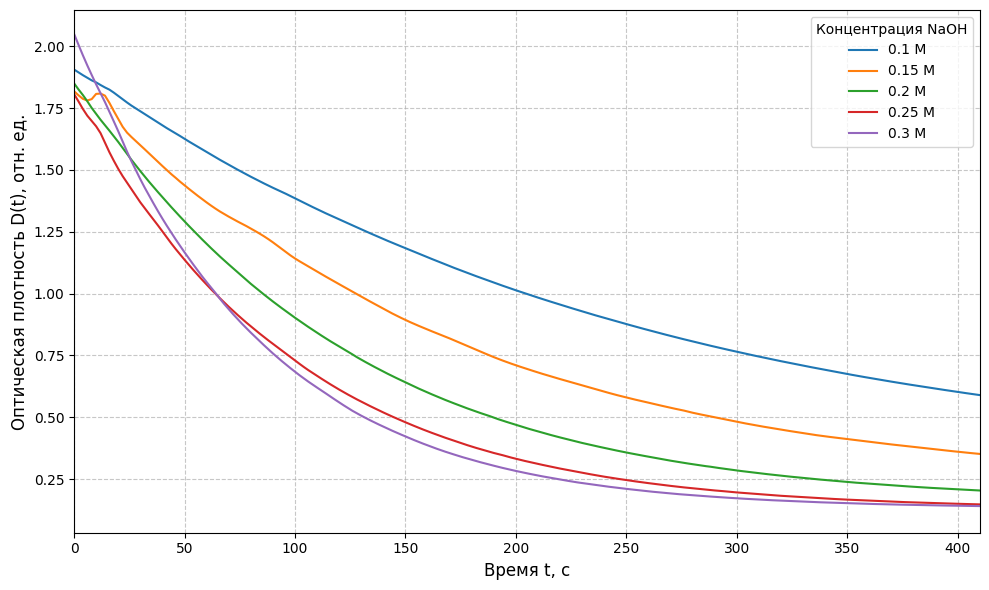

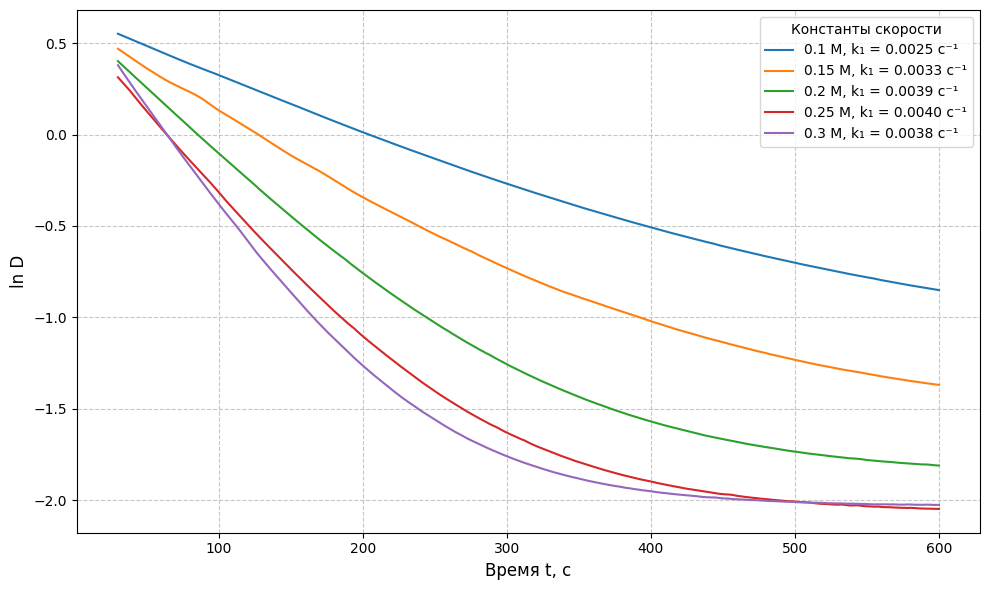

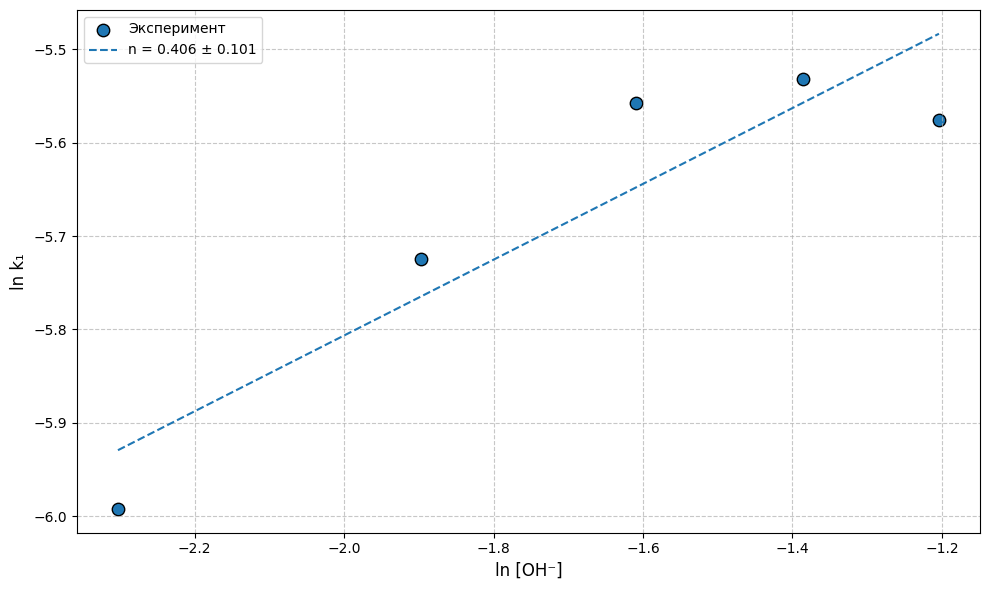


Результаты:
n = 0.406 ± 0.101
k2 = 0.006775 ± 0.001179 М⁻¹·с⁻¹


In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import os


# merged уже должен быть создан ранее
# Первый столбец — время, остальные — D(t)

time_col = merged.columns[0]
data_cols = merged.columns[1:]

# Переводим все в числа
for col in merged.columns:
    merged[col] = pd.to_numeric(merged[col], errors="coerce")

# Не делаем merged.dropna(), иначе можно потерять начало данных
merged = merged.dropna(subset=[time_col])

print("Столбец времени:", time_col)
print("Столбцы D(t):", list(data_cols))
print("Минимальное время:", merged[time_col].min())


# Соответствие концентраций и столбцов
columns = {
    0.10: "IV1_2",
    0.15: "IV1_1",
    0.20: "IV1_4",
    0.25: "IV1_5",
    0.30: "IV1_6",
}

fit_start_time = 30

concs_list = []
k1_list = []
plot_data = []


for conc, col in sorted(columns.items()):
    if col not in merged.columns:
        print(f"Столбец {col} не найден, пропускаю.")
        continue

    t = merged[time_col]
    D = merged[col]

    # Аппроксимация только после fit_start_time
    mask_fit = (
        (t >= fit_start_time)
        & t.notna()
        & D.notna()
        & (D > 0)
    )

    t_fit = t[mask_fit]
    ln_D_fit = np.log(D[mask_fit])

    res = linregress(t_fit, ln_D_fit)
    k1 = -res.slope

    concs_list.append(conc)
    k1_list.append(k1)
    plot_data.append((conc, t, D, k1, res))

    print(f"{col}: C = {conc:.2f} M, k1 = {k1:.6f} c⁻¹, R² = {res.rvalue**2:.4f}")


# -------------------------------
# 1. График D(t), без обрезания начала
# -------------------------------

plt.figure(figsize=(10, 6))

for conc, t, D, k1, res in plot_data:
    mask = t.notna() & D.notna()

    plt.plot(
        t[mask],
        D[mask],
        label=f"{conc} M"
    )

plt.xlim(left=0, right=410)
plt.xlabel("Время t, с", fontsize=12)
plt.ylabel("Оптическая плотность D(t), отн. ед.", fontsize=12)
plt.legend(title="Концентрация NaOH", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("1_Kinetics_D_t.png", dpi=300, bbox_inches="tight")
plt.show()


# -------------------------------
# 2. Линеаризация ln D(t)
# -------------------------------

plt.figure(figsize=(10, 6))

for conc, t, D, k1, res in plot_data:
    mask = (
        (t >= fit_start_time)
        & t.notna()
        & D.notna()
        & (D > 0)
    )

    t_segment = t[mask]
    ln_D_segment = np.log(D[mask])

    plt.plot(
        t_segment,
        ln_D_segment,
        label=f"{conc} M, k₁ = {k1:.4f} c⁻¹"
    )

plt.xlabel("Время t, с", fontsize=12)
plt.ylabel("ln D", fontsize=12)
plt.legend(title="Константы скорости", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("2_Linearization_lnD.png", dpi=300, bbox_inches="tight")
plt.show()


# -------------------------------
# 3. Определение порядка реакции
# -------------------------------

concs_arr = np.array(concs_list)
k1_arr = np.array(k1_list)

valid = (concs_arr > 0) & (k1_arr > 0)

ln_concs = np.log(concs_arr[valid])
ln_k1 = np.log(k1_arr[valid])

res_n = linregress(ln_concs, ln_k1)

n_value = res_n.slope
n_error = res_n.stderr

k2_value = np.exp(res_n.intercept)
intercept_error = res_n.intercept_stderr
k2_error = k2_value * intercept_error

plt.figure(figsize=(10, 6))

plt.scatter(
    ln_concs,
    ln_k1,
    edgecolor="black",
    s=80,
    label="Эксперимент"
)

x_line = np.linspace(ln_concs.min(), ln_concs.max(), 100)
y_line = res_n.intercept + res_n.slope * x_line

plt.plot(
    x_line,
    y_line,
    "--",
    label=f"n = {n_value:.3f} ± {n_error:.3f}"
)

plt.xlabel("ln [OH⁻]", fontsize=12)
plt.ylabel("ln k₁", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("3_Order_Determination.png", dpi=300, bbox_inches="tight")
plt.show()


print("\nРезультаты:")
print(f"n = {n_value:.3f} ± {n_error:.3f}")
print(f"k2 = {k2_value:.6f} ± {k2_error:.6f} М⁻¹·с⁻¹")

In [50]:
import os
import glob
import re
import numpy as np
import pandas as pd


folder = "kinetika/CData/"


def natural_key(path):
    name = os.path.basename(path)
    return [
        int(part) if part.isdigit() else part.lower()
        for part in re.split(r"(\d+)", name)
    ]


# Берем только файлы IV2 и сортируем по алфавиту/номерам
files = sorted(
    glob.glob(os.path.join(folder, "IV2*.csv")),
    key=natural_key
)

print("Найденные файлы IV2 в порядке:")
for file in files:
    print(os.path.basename(file))


def read_iv_file(path):
    name = os.path.splitext(os.path.basename(path))[0]

    df = pd.read_csv(path)

    df = df.reset_index()

    df = df.iloc[:, :2].copy()
    df.columns = ["Time_Sec", name]

    df["Time_Sec"] = df["Time_Sec"].astype(str).str.replace(",", ".", regex=False)
    df[name] = df[name].astype(str).str.replace(",", ".", regex=False)

    df["Time_Sec"] = pd.to_numeric(df["Time_Sec"], errors="coerce")
    df[name] = pd.to_numeric(df[name], errors="coerce")

    df = df.dropna(subset=["Time_Sec", name])

    return df


tables2 = [read_iv_file(file) for file in files]

if len(tables2) == 0:
    raise ValueError("Не найдено файлов IV2*.csv в указанной папке.")

merged2 = tables2[0]

for table in tables2[1:]:
    merged2 = pd.merge(
        merged2,
        table,
        on="Time_Sec",
        how="outer"
    )

merged2 = merged2.sort_values("Time_Sec").reset_index(drop=True)

time2_np = merged2["Time_Sec"].to_numpy()
values2_np = merged2.drop(columns=["Time_Sec"]).to_numpy()
data2_np = merged2.to_numpy()

print("\nИтоговая таблица merged2:")
print(merged2.head())

print("\nСтолбцы итоговой таблицы:")
print(list(merged2.columns))

merged2.to_csv(os.path.join(folder, "IV2_merged.csv"), index=False)
np.save(os.path.join(folder, "IV2_merged.npy"), data2_np)
np.save(os.path.join(folder, "IV2_time.npy"), time2_np)
np.save(os.path.join(folder, "IV2_values.npy"), values2_np)

Найденные файлы IV2 в порядке:
IV2_1.csv
IV2_2.csv
IV2_3.csv
IV2_merged.csv
IV24.csv
IV25.csv
IV26.csv

Итоговая таблица merged2:
   Time_Sec   IV2_1   IV2_2   IV2_3  IV2_merged    IV24   IV25    IV26
0       0.0  1.8420  1.9715  1.9367         0.0  1.6975  1.962  2.1157
1       1.0     NaN     NaN     NaN         1.0     NaN    NaN     NaN
2       2.0  1.8339  1.9557  1.9180         2.0  1.6886  1.945  2.0934
3       3.0     NaN     NaN     NaN         3.0     NaN    NaN     NaN
4       4.0  1.8247  1.9406  1.9013         4.0  1.6790  1.929  2.0736

Столбцы итоговой таблицы:
['Time_Sec', 'IV2_1', 'IV2_2', 'IV2_3', 'IV2_merged', 'IV24', 'IV25', 'IV26']


In [1]:
import os
import glob
import re
import numpy as np
import pandas as pd


folder = "kinetika/CData/"


def natural_key(path):
    """
    Нормальная сортировка:
    IV2_1.csv, IV2_2.csv, ..., IV2_10.csv
    а не IV2_1.csv, IV2_10.csv, IV2_2.csv
    """
    name = os.path.basename(path)
    return [
        int(part) if part.isdigit() else part.lower()
        for part in re.split(r"(\d+)", name)
    ]


# Берем все файлы IV*.csv из папки
files = sorted(
    glob.glob(os.path.join(folder, "IV2*.csv")),
    key=natural_key
)

print("Найденные файлы:")
for file in files:
    print(os.path.basename(file))


def read_iv_file(path):
    name = os.path.splitext(os.path.basename(path))[0]

    df = pd.read_csv(path)

    # В этих файлах время оказалось в индексе,
    # поэтому возвращаем индекс в обычный столбец
    df = df.reset_index()

    # Берем первые два столбца: время и оптическую плотность
    df = df.iloc[:, :2].copy()
    df.columns = ["Time_Sec", name]

    # Заменяем десятичные запятые на точки
    df["Time_Sec"] = df["Time_Sec"].astype(str).str.replace(",", ".", regex=False)
    df[name] = df[name].astype(str).str.replace(",", ".", regex=False)

    # Переводим в числа
    df["Time_Sec"] = pd.to_numeric(df["Time_Sec"], errors="coerce")
    df[name] = pd.to_numeric(df[name], errors="coerce")

    # Убираем строки с мусором
    df = df.dropna(subset=["Time_Sec", name])

    return df


tables2 = [read_iv_file(file) for file in files]

if len(tables2) == 0:
    raise ValueError("Не найдено файлов IV*.csv в указанной папке.")

merged2 = tables2[0]

for table in tables2[1:]:
    merged2 = pd.merge(
        merged2,
        table,
        on="Time_Sec",
        how="outer"
    )

merged2 = merged2.sort_values("Time_Sec").reset_index(drop=True)

# numpy-массивы
time2_np = merged2["Time_Sec"].to_numpy()
values2_np = merged2.drop(columns=["Time_Sec"]).to_numpy()
data2_np = merged2.to_numpy()

print("\nИтоговая таблица merged2:")
print(merged2.head())

print("\nСтолбцы merged2:")
print(list(merged2.columns))

print("\nРазмер data2_np:", data2_np.shape)
print("Размер time2_np:", time2_np.shape)
print("Размер values2_np:", values2_np.shape)

# Сохранение итоговой таблицы
merged2.to_csv(os.path.join(folder, "merged2.csv"), index=False)

np.save(os.path.join(folder, "merged2.npy"), data2_np)
np.save(os.path.join(folder, "merged2_time.npy"), time2_np)
np.save(os.path.join(folder, "merged2_values.npy"), values2_np)

Найденные файлы:
IV21.csv
IV22.csv
IV23.csv
IV24.csv
IV25.csv
IV26.csv

Итоговая таблица merged2:
   Time_Sec    IV21    IV22    IV23    IV24    IV25    IV26
0       0.0  1.8420  1.9715  1.9367  1.6975  1.9620  2.1157
1       2.0  1.8339  1.9557  1.9180  1.6886  1.9450  2.0934
2       4.0  1.8247  1.9406  1.9013  1.6790  1.9290  2.0736
3       6.0  1.8153  1.9242  1.8839  1.6686  1.9137  2.0563
4       8.0  1.8062  1.9063  1.8664  1.6567  1.8940  2.0416

Столбцы merged2:
['Time_Sec', 'IV21', 'IV22', 'IV23', 'IV24', 'IV25', 'IV26']

Размер data2_np: (301, 7)
Размер time2_np: (301,)
Размер values2_np: (301, 6)


I = 0.1 (IV21): k1 = 0.001999 c⁻¹, R² = 0.9921
I = 0.8 (IV22): k1 = 0.003095 c⁻¹, R² = 0.9706
I = 1 (IV23): k1 = 0.003117 c⁻¹, R² = 0.9617
I = 1.2 (IV24): k1 = 0.002831 c⁻¹, R² = 0.9552
I = 1.4 (IV25): k1 = 0.003239 c⁻¹, R² = 0.9615
I = 1.6 (IV26): k1 = 0.003250 c⁻¹, R² = 0.9549


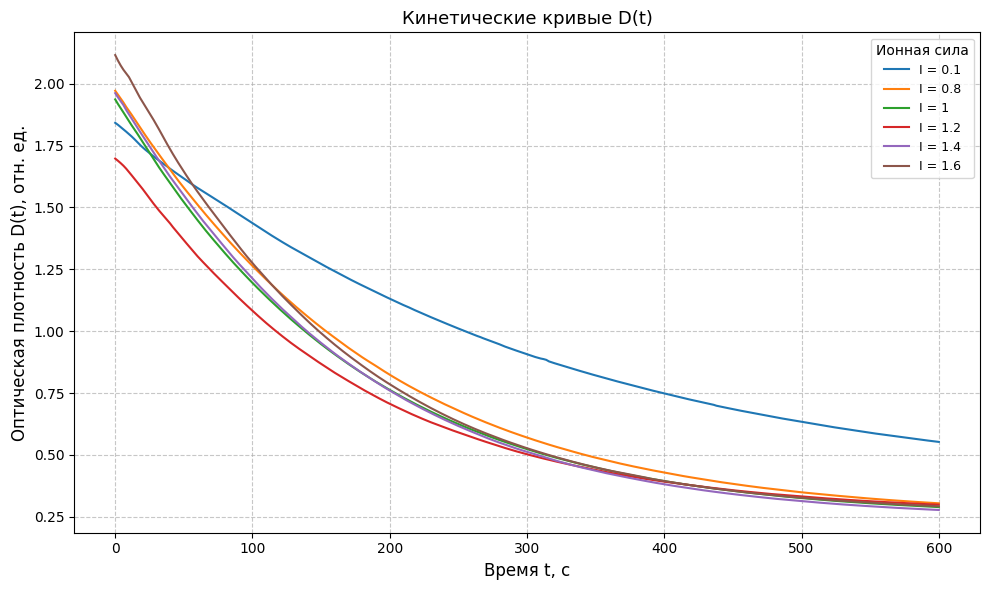

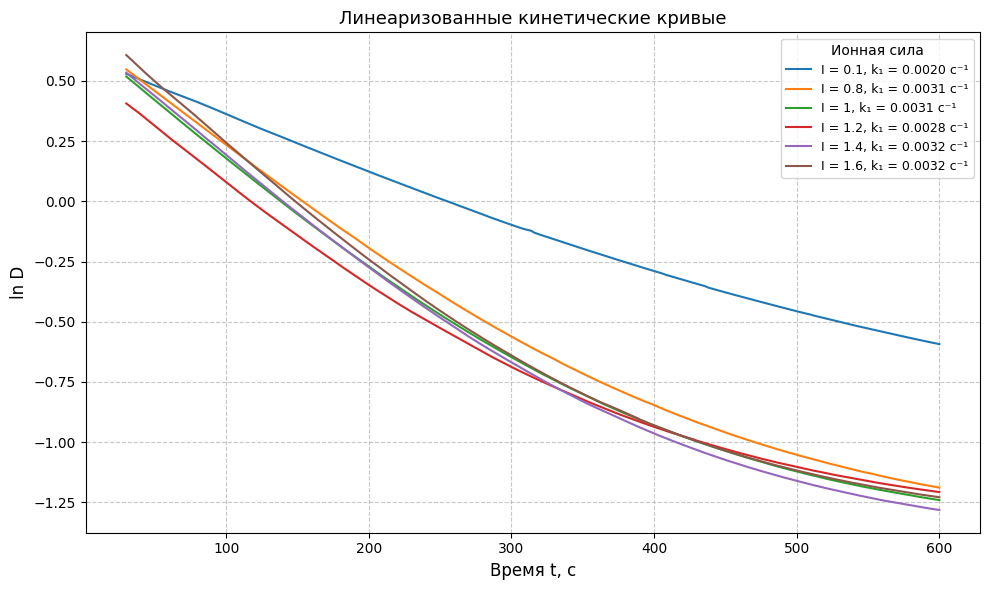

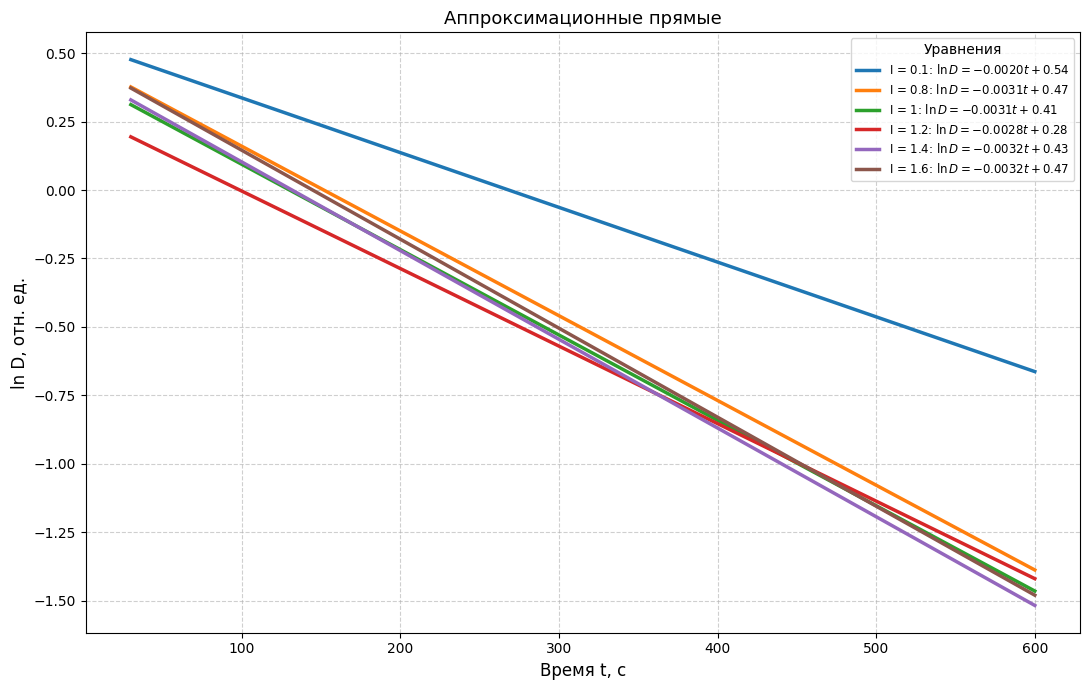

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress


folder = "kinetika/CData/"
file_path = os.path.join(folder, "merged2.csv")

df = pd.read_csv(file_path)

df.columns = df.columns.str.strip()

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

time_col = df.columns[0]
df = df.dropna(subset=[time_col])

data_cols = list(df.columns[1:])

I_values = [0.1, 0.8, 1, 1.2, 1.4, 1.6]

if len(I_values) != len(data_cols):
    raise ValueError(
        f"Количество I_values ({len(I_values)}) не совпадает "
        f"с количеством столбцов данных ({len(data_cols)}): {data_cols}"
    )

labels = {
    col: f"I = {I:g}"
    for col, I in zip(data_cols, I_values)
}

fit_start_time = 30

plot_data = []

for col in data_cols:
    t = df[time_col]
    D = df[col]

    mask_fit = (
        (t >= fit_start_time)
        & t.notna()
        & D.notna()
        & (D > 0)
    )

    t_fit = t[mask_fit]
    ln_D_fit = np.log(D[mask_fit])

    if len(t_fit) < 2:
        print(f"{col}: слишком мало точек для аппроксимации, пропускаю.")
        continue

    res = linregress(t_fit, ln_D_fit)
    k1 = -res.slope

    plot_data.append({
        "name": col,
        "label": labels[col],
        "I": I_values[data_cols.index(col)],
        "t": t,
        "D": D,
        "t_fit": t_fit,
        "ln_D_fit": ln_D_fit,
        "slope": res.slope,
        "intercept": res.intercept,
        "k1": k1,
        "R2": res.rvalue**2
    })

    print(
        f"{labels[col]} ({col}): "
        f"k1 = {k1:.6f} c⁻¹, "
        f"R² = {res.rvalue**2:.4f}"
    )


# -------------------------------
# 1. График D(t)
# -------------------------------

plt.figure(figsize=(10, 6))

for d in plot_data:
    mask = d["t"].notna() & d["D"].notna()

    plt.plot(
        d["t"][mask],
        d["D"][mask],
        label=d["label"]
    )

plt.xlabel("Время t, с", fontsize=12)
plt.ylabel("Оптическая плотность D(t), отн. ед.", fontsize=12)
plt.title("Кинетические кривые D(t)", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(title="Ионная сила", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(folder, "merged2_1_Kinetics_D_t.png"), dpi=300, bbox_inches="tight")
plt.show()


# -------------------------------
# 2. Линеаризация ln D(t)
# -------------------------------

plt.figure(figsize=(10, 6))

for d in plot_data:
    plt.plot(
        d["t_fit"],
        d["ln_D_fit"],
        label=f"{d['label']}, k₁ = {d['k1']:.4f} c⁻¹"
    )

plt.xlabel("Время t, с", fontsize=12)
plt.ylabel("ln D", fontsize=12)
plt.title("Линеаризованные кинетические кривые", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(title="Ионная сила", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(folder, "merged2_2_Linearization_lnD.png"), dpi=300, bbox_inches="tight")
plt.show()


# -------------------------------
# 3. Только аппроксимационные прямые
# -------------------------------

plt.figure(figsize=(11, 7))

for d in plot_data:
    ln_D_theoretical = d["slope"] * d["t_fit"] + d["intercept"]

    eqn = (
        f"{d['label']}: "
        f"$\\ln D = {d['slope']:.4f}t {d['intercept']:+.2f}$"
    )

    plt.plot(
        d["t_fit"],
        ln_D_theoretical,
        label=eqn,
        linewidth=2.5
    )

plt.xlabel("Время t, с", fontsize=12)
plt.ylabel("ln D, отн. ед.", fontsize=12)
plt.title("Аппроксимационные прямые", fontsize=13)
plt.legend(title="Уравнения", fontsize=8.5, loc="best")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(folder, "merged2_3_Linearization_Perfect_Lines.png"), dpi=300, bbox_inches="tight")
plt.show()

In [5]:
# -----------------------------
# Приводим к numpy-массивам
# -----------------------------
J_vals = np.array(J_vals, dtype=float)
k1_vals = np.array(k1_vals, dtype=float)

valid = np.isfinite(J_vals) & np.isfinite(k1_vals) & (k1_vals > 0)

J_vals = J_vals[valid]
k1_vals = k1_vals[valid]

log_k1 = np.log10(k1_vals)

A_39 = 0.5254

f_DHL = np.sqrt(J_vals)
f_DHE = np.sqrt(J_vals) / (1 + np.sqrt(J_vals))
f_Davies = (np.sqrt(J_vals) / (1 + np.sqrt(J_vals))) - 0.2 * J_vals


def plot_model(x, y, label):
    res = linregress(x, y)
    zazb = res.slope / (2 * A_39)

    plt.scatter(x, y, edgecolor="black", s=60)

    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = res.intercept + res.slope * x_line

    plt.plot(
        x_line,
        y_line,
        label=(
            f"{label}: y = {res.slope:.2f}x {res.intercept:+.2f}\n"
            f"$Z_A Z_B$ = {zazb:.2f}, $R^2$ = {res.rvalue**2:.3f}"
        )
    )

    return res


plt.figure(figsize=(12, 8))

res_davies = plot_model(f_Davies, log_k1, "Davies")
res_dhe = plot_model(f_DHE, log_k1, "DHE")
res_dhl = plot_model(f_DHL, log_k1, "DHL")

plt.xlabel(r"$f(I)$", fontsize=12)
plt.ylabel(r"$\log_{10} k_1$", fontsize=12)
plt.title("Сравнение моделей первичного солевого эффекта", fontsize=13)
plt.legend(fontsize=9, loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(folder, "Salt_Effect_Comparison.png"), dpi=300)
plt.show()

print("\nИтог:")
print(f"Теоретический наклон для десятичного логарифма: 2*A*Z_A*Z_B ≈ {2 * A_39 * 2:.2f}")
print(f"Davies: slope = {res_davies.slope:.3f}, Z_A Z_B = {res_davies.slope / (2*A_39):.3f}")
print(f"DHE:    slope = {res_dhe.slope:.3f}, Z_A Z_B = {res_dhe.slope / (2*A_39):.3f}")
print(f"DHL:    slope = {res_dhl.slope:.3f}, Z_A Z_B = {res_dhl.slope / (2*A_39):.3f}")

NameError: name 'J_vals' is not defined

In [67]:
import os
import numpy as np
import pandas as pd


folder = "kinetika/CData/"

# Уже собранный файл по вторым данным
merged2_path = os.path.join(folder, "merged2.csv")

# Читаем готовую суммарную таблицу
merged2 = pd.read_csv(merged2_path)

# Чистим названия столбцов
merged2.columns = merged2.columns.str.strip()

# Переводим все данные в числа
for col in merged2.columns:
    merged2[col] = pd.to_numeric(merged2[col], errors="coerce")

# Первый столбец считаем временем
time_col = merged2.columns[0]

# Переименуем первый столбец в Time_Sec, если он называется иначе
if time_col != "Time_Sec":
    merged2 = merged2.rename(columns={time_col: "Time_Sec"})

# Убираем только строки без времени
merged2 = merged2.dropna(subset=["Time_Sec"])

# Сортируем по времени
merged2 = merged2.sort_values("Time_Sec").reset_index(drop=True)

# numpy-массивы
time2_np = merged2["Time_Sec"].to_numpy()
values2_np = merged2.drop(columns=["Time_Sec"]).to_numpy()
data2_np = merged2.to_numpy()

print("\nИтоговая таблица merged2:")
print(merged2.head())

print("\nСтолбцы merged2:")
print(list(merged2.columns))

print("\nРазмер data2_np:", data2_np.shape)
print("Размер time2_np:", time2_np.shape)
print("Размер values2_np:", values2_np.shape)

# Сохраняем обратно очищенную версию, если нужно
merged2.to_csv(os.path.join(folder, "merged2_clean.csv"), index=False)

np.save(os.path.join(folder, "merged2.npy"), data2_np)
np.save(os.path.join(folder, "merged2_time.npy"), time2_np)
np.save(os.path.join(folder, "merged2_values.npy"), values2_np)


Итоговая таблица merged2:
   Time_Sec    IV21    IV22    IV23    IV24    IV25    IV26
0       0.0  1.8420  1.9715  1.9367  1.6975  1.9620  2.1157
1       2.0  1.8339  1.9557  1.9180  1.6886  1.9450  2.0934
2       4.0  1.8247  1.9406  1.9013  1.6790  1.9290  2.0736
3       6.0  1.8153  1.9242  1.8839  1.6686  1.9137  2.0563
4       8.0  1.8062  1.9063  1.8664  1.6567  1.8940  2.0416

Столбцы merged2:
['Time_Sec', 'IV21', 'IV22', 'IV23', 'IV24', 'IV25', 'IV26']

Размер data2_np: (301, 7)
Размер time2_np: (301,)
Размер values2_np: (301, 6)


Столбец времени: Time_Sec
Столбцы данных: ['IV21', 'IV22', 'IV23', 'IV24', 'IV25', 'IV26']
IV21: I = 0.10, k1 = 0.001999 ± 0.000011 c^-1, R^2 = 0.9921
IV22: I = 0.80, k1 = 0.003095 ± 0.000032 c^-1, R^2 = 0.9706
IV23: I = 1.00, k1 = 0.003117 ± 0.000037 c^-1, R^2 = 0.9617
IV24: I = 1.20, k1 = 0.002831 ± 0.000036 c^-1, R^2 = 0.9552
IV25: I = 1.40, k1 = 0.003239 ± 0.000038 c^-1, R^2 = 0.9615
IV26: I = 1.60, k1 = 0.003250 ± 0.000042 c^-1, R^2 = 0.9549


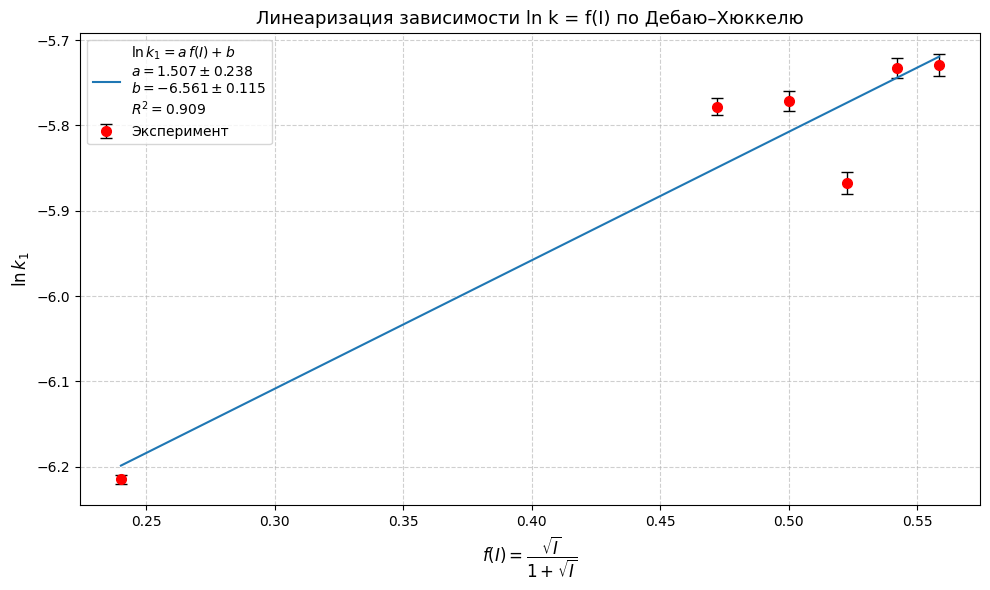


Итоговые значения:
I = 0.10, f(I) = 0.2403, k1 = 0.001999 ± 0.000011 c^-1, ln(k1) = -6.2150 ± 0.0053
I = 0.80, f(I) = 0.4721, k1 = 0.003095 ± 0.000032 c^-1, ln(k1) = -5.7779 ± 0.0103
I = 1.00, f(I) = 0.5000, k1 = 0.003117 ± 0.000037 c^-1, ln(k1) = -5.7708 ± 0.0118
I = 1.20, f(I) = 0.5228, k1 = 0.002831 ± 0.000036 c^-1, ln(k1) = -5.8670 ± 0.0129
I = 1.40, f(I) = 0.5420, k1 = 0.003239 ± 0.000038 c^-1, ln(k1) = -5.7324 ± 0.0119
I = 1.60, f(I) = 0.5585, k1 = 0.003250 ± 0.000042 c^-1, ln(k1) = -5.7292 ± 0.0129

Параметры линейной аппроксимации:
slope = 1.506825 ± 0.238276
intercept = -6.560848 ± 0.115490
R^2 = 0.909073


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress


# ============================================================
# НАСТРОЙКИ
# ============================================================

folder = "kinetika/CData/"
file_path = os.path.join(folder, "merged2.csv")

# Ионные силы в порядке столбцов merged2.csv
I_values = np.array([0.1, 0.8, 1, 1.2, 1.4, 1.6], dtype=float)

# С какого времени делать линеаризацию ln D(t)
fit_start_time = 30

# Параметр A при 39°C
A_39 = 0.5254


# ============================================================
# ЧТЕНИЕ ГОТОВОЙ СУММАРНОЙ ТАБЛИЦЫ
# ============================================================

df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

time_col = df.columns[0]
df = df.dropna(subset=[time_col])

data_cols = list(df.columns[1:])

if len(I_values) != len(data_cols):
    raise ValueError(
        f"Количество I_values ({len(I_values)}) не совпадает "
        f"с количеством столбцов данных ({len(data_cols)}): {data_cols}"
    )

print("Столбец времени:", time_col)
print("Столбцы данных:", data_cols)


# ============================================================
# РАСЧЕТ k1 И ЕГО ПОГРЕШНОСТИ
# ln D = ln D0 - k1*t
# slope = -k1
# sigma(k1) = stderr(slope)
# sigma(ln k1) = sigma(k1)/k1
# ============================================================

k1_vals = []
k1_errs = []

for I, col in zip(I_values, data_cols):
    t = df[time_col]
    D = df[col]

    mask_fit = (
        (t >= fit_start_time)
        & t.notna()
        & D.notna()
        & (D > 0)
    )

    t_fit = t[mask_fit]
    ln_D_fit = np.log(D[mask_fit])

    if len(t_fit) < 2:
        print(f"{col}: слишком мало точек для аппроксимации, пропускаю.")
        k1_vals.append(np.nan)
        k1_errs.append(np.nan)
        continue

    res = linregress(t_fit, ln_D_fit)

    k1 = -res.slope
    k1_err = res.stderr

    k1_vals.append(k1)
    k1_errs.append(k1_err)

    print(
        f"{col}: I = {I:.2f}, "
        f"k1 = {k1:.6f} ± {k1_err:.6f} c^-1, "
        f"R^2 = {res.rvalue**2:.4f}"
    )

k1_vals = np.array(k1_vals, dtype=float)
k1_errs = np.array(k1_errs, dtype=float)

valid = (
    np.isfinite(I_values)
    & np.isfinite(k1_vals)
    & np.isfinite(k1_errs)
    & (k1_vals > 0)
    & (k1_errs >= 0)
)

I_vals = I_values[valid]
k1_vals = k1_vals[valid]
k1_errs = k1_errs[valid]


# ============================================================
# ДЕБАЙ–ХЮККЕЛЬ: f(I)
# 2-е приближение
# ============================================================

f_I = np.sqrt(I_vals) / (1 + np.sqrt(I_vals))

# Если нужен вариант из отчета:
# f_I = np.sqrt(I_vals) / (1 + 0.987 * np.sqrt(I_vals))

ln_k1 = np.log(k1_vals)
ln_k1_err = k1_errs / k1_vals   # распространение погрешности


# ============================================================
# ЛИНЕЙНАЯ РЕГРЕССИЯ ln k = a*f(I) + b
# ============================================================

res_salt = linregress(f_I, ln_k1)

slope = res_salt.slope
intercept = res_salt.intercept
slope_err = res_salt.stderr
intercept_err = res_salt.intercept_stderr
R2 = res_salt.rvalue**2

# Для ln-формы:
# ln k = ln k0 + 2 * 2.303 * A * Z_A Z_B * f(I)
# Но если используем ln, то удобнее:
# ln k = ln k0 + 2 * A * Z_A Z_B * f(I)   <-- в упрощенной записи из школьной обработки часто так не пишут
# В твоем отчете был наклон:
# tg(alpha) = 2.303 * 2 * A * Z_A Z_B
# Это соответствовало переходу между lg и ln в записи.
#
# Чтобы не путаться, здесь просто выводим экспериментальный наклон.
# Если хочешь, можно отдельно восстановить Z_A Z_B по той формуле, которую вы используете в отчете.


# ============================================================
# ГРАФИК: ln k = f(I)
# ============================================================

plt.figure(figsize=(10, 6))

# Красные экспериментальные точки с погрешностями
plt.errorbar(
    f_I,
    ln_k1,
    yerr=ln_k1_err,
    fmt='o',
    color='red',
    ecolor='black',
    elinewidth=1,
    capsize=4,
    markersize=7,
    label='Эксперимент'
)

# Аппроксимационная прямая
x_line = np.linspace(f_I.min(), f_I.max(), 200)
y_line = intercept + slope * x_line

plt.plot(
    x_line,
    y_line,
    label=(
        r"$\ln k_1 = a\,f(I) + b$" "\n"
        rf"$a = {slope:.3f} \pm {slope_err:.3f}$" "\n"
        rf"$b = {intercept:.3f} \pm {intercept_err:.3f}$" "\n"
        rf"$R^2 = {R2:.3f}$"
    )
)

plt.xlabel(r"$f(I)=\dfrac{\sqrt{I}}{1+\sqrt{I}}$", fontsize=12)
plt.ylabel(r"$\ln k_1$", fontsize=12)
plt.title("Линеаризация зависимости ln k = f(I) по Дебаю–Хюккелю", fontsize=13)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(folder, "3_Corrected_Salt_Effect.png"), dpi=300, bbox_inches='tight')
plt.show()


# ============================================================
# ВЫВОД ЧИСЛЕННЫХ РЕЗУЛЬТАТОВ
# ============================================================

print("\nИтоговые значения:")
for I, fi, k, dk, lnk, dlnk in zip(I_vals, f_I, k1_vals, k1_errs, ln_k1, ln_k1_err):
    print(
        f"I = {I:.2f}, "
        f"f(I) = {fi:.4f}, "
        f"k1 = {k:.6f} ± {dk:.6f} c^-1, "
        f"ln(k1) = {lnk:.4f} ± {dlnk:.4f}"
    )

print("\nПараметры линейной аппроксимации:")
print(f"slope = {slope:.6f} ± {slope_err:.6f}")
print(f"intercept = {intercept:.6f} ± {intercept_err:.6f}")
print(f"R^2 = {R2:.6f}")

In [71]:
import numpy as np

num_exp = int(input("Enter number of experiments for equal ion power "))
volume = float(input("Enter volume of one batch, ml "))

print("Volume of 0.3 NaOH, ml:", (np.linspace(0.3, 0.05, num_exp)*volume/0.3))
print("Volume of 0.3 NaCl, ml:", (np.linspace(0.3, 0.3, num_exp)*volume/0.3 - np.linspace(0.3, 0.05, num_exp)*volume/0.3))


num_exp = int(input("Enter number of experiments for differnt ion power "))
volume = float(input("Enter volume of one batch, ml "))

print("Volume of Naoh, ml:", np.linspace(volume/3, volume/3, num_exp))
print("Volume of NaCl 2.4M, ml:", (np.linspace(0.1, 1.7, num_exp) - 0.1)*volume/2.4)
print("Volume of H2O, ml:", np.linspace(volume/3, volume/3, num_exp)*2 - (np.linspace(0.1, 1.7, num_exp) - 0.1)*volume/2.4)




Enter number of experiments for equal ion power  6
Enter volume of one batch, ml  3


Volume of 0.3 NaOH, ml: [3.  2.5 2.  1.5 1.  0.5]
Volume of 0.3 NaCl, ml: [0.  0.5 1.  1.5 2.  2.5]


Enter number of experiments for differnt ion power  6
Enter volume of one batch, ml  3


Volume of Naoh, ml: [1. 1. 1. 1. 1. 1.]
Volume of NaCl 2.4M, ml: [0.  0.4 0.8 1.2 1.6 2. ]
Volume of H2O, ml: [2.  1.6 1.2 0.8 0.4 0. ]
